In [1]:
import requests
url = "https://raw.githubusercontent.com/sahoo00/BooleanAnalysis/refs/heads/main/BoNEWeb.py"
exec(requests.get(url).text)
url = "https://raw.githubusercontent.com/sahoo00/BooleanAnalysis/refs/heads/main/HegemonUtil.py"
exec(requests.get(url).text)

<string>:382: SyntaxWarning: "is" with a literal. Did you mean "=="?


In [2]:
def printSurvival(self, fthr = None, pG = None, ct = None, ax = None):
    f_ranks = self.f_ranks
    order = self.order
    thr = hu.getThrData(f_ranks)
    #thr = hu.getThrData([f_ranks[i - self.start] for i in order])
    nm1 = (np.max(f_ranks) - np.min(f_ranks))/16
    nm = self.noisemargin
    if fthr is None:
        fthr = thr[0]
    if fthr == "thr0":
        fthr = thr[0] - nm
    if fthr == "thr1":
        fthr = thr[0]
    if fthr == "thr2":
        fthr = thr[0] + nm
    if fthr == "thr.5":
        fthr = thr[0] + 0.5 * nm
    if fthr == "thr-.5":
        fthr = thr[0] - 0.5 * nm
    if fthr == "thr1.5":
        fthr = thr[0] + 1.5 * nm
    if fthr == "thr2.5":
        fthr = thr[0] + 2.5 * nm
    if fthr == "thr3":
        fthr = thr[0] + 3 * nm
    if fthr == "thr+thr1":
        v1 = [f_ranks[i - self.start] for i in order
                if f_ranks[i - self.start] >= thr[0]]
        thr2 = hu.getThrData(v1)
        print(thr2)
        fthr = thr2[0]
    if fthr == "thr-thr1":
        v1 = [f_ranks[i - self.start] for i in order
                if f_ranks[i - self.start] < thr[0]]
        thr2 = hu.getThrData(v1)
        print(thr2)
        fthr = thr2[0]
    if fthr == "avg":
        fthr = np.mean([f_ranks[i - self.start] for i in order])
    if fthr == "med":
        fthr = np.median([f_ranks[i - self.start] for i in order])
    print(thr)
    print(fthr, nm, nm1, thr[0] + nm1)
    g1 = [i for i in order if f_ranks[i - self.start] < fthr]
    g2 = [i for i in order if f_ranks[i - self.start] >= fthr]
    if pG is None:
        pG = [ ["Low", "red", g1], ["High", "green", g2]]
    time = self.getSurvName('time')
    status = self.getSurvName('status')
    if ct is not None:
        time, status = hu.censor(time, status, ct)
    sax = hu.survival(time, status, pG, ax)
    return sax
BooleanAnalysis.printSurvival = printSurvival
def getSurvival(self, dbid = "CRC35.3"):
    self.prepareDataDf(dbid)
    atype = self.getSurvName("status")
    atypes = ['Censor', 'Relapse']
    ahash = {"0": 0, "1":1}
    self.initData(atype, atypes, ahash)
    return
BooleanAnalysis.getSurvival = getSurvival
    
def getJSTOM(self):
    self.getSurvival("CRC35.3")
    return
BooleanAnalysis.getJSTOM = getJSTOM
def printTestSurvival(l1, wt1, fthr, ax = None):
    ana = BooleanAnalysis()
    ana.getJSTOM()
    ana.orderDataDf(l1, wt1)
    sax = ana.printSurvival(fthr, None, None, None)
    sax.set_title(ana.getTitle())
    return sax
def readGenes(url):
    res = requests.get(url).text
    return [i for i in hu.uniq(res.split("\n")) if i != '']
def printTestSurvival2(l1, wt1, fthr, ax = None):
    ana = BooleanAnalysis()
    ana.getSurvival("LIV15.2")
    ana.orderDataDf(l1, wt1)
    sax = ana.printSurvival(fthr, None, None, None)
    sax.set_title(ana.getTitle())
    return sax

def printTestSurvival3(l1, wt1, fthr, ax = None):
    ana = BooleanAnalysis()
    ana.getSurvival("MAC104")
    ana.orderDataDf(l1, wt1)
    sax = ana.printSurvival(fthr, None, None, None)
    sax.set_title(ana.getTitle())
    return sax

def printTestSurvival4(l1, wt1, i1, i2, i3, ax = None):
    ana = BooleanAnalysis()
    ana.getSurvival("MACV74")
    ana.orderDataDf(l1, wt1)
    time = ana.getSurvName('time')
    status = ana.getSurvName('status')
    time1 = [time[i] for i in ana.order]
    status1 = [status[i] for i in ana.order]
    thr = hu.getThrData(ana.f_ranks)
    nm = (np.max(ana.f_ranks) - np.min(ana.f_ranks))/16
    print(thr, nm)
    fthr = -800
    fthr = thr[0]
    print(fthr)
    group1 = [1 if ana.f_ranks[i - ana.start] > fthr else 0 for i in ana.order]

    ana = BooleanAnalysis()
    ana.getSurvival("MACV75")
    ana.orderDataDf(l1, wt1)
    time = ana.getSurvName('time')
    status = ana.getSurvName('status')
    time2 = [time[i] for i in ana.order]
    status2 = [status[i] for i in ana.order]
    v1 = sorted([ana.f_ranks[i - ana.start] for i in ana.order])
    thr = hu.getThrData(v1[:-1])
    nm = ana.noisemargin
    #nm = (np.max(ana.f_ranks) - np.min(ana.f_ranks))/16
    print(thr, nm)
    fthr = -342
    fthr = thr[0] - int(nm)
    print(fthr)
    group2 = [1 if ana.f_ranks[i - ana.start] > fthr else 0 for i in ana.order]

    df = pd.DataFrame()
    df['time'] = time1 + time2
    df['status'] = status1 + status2
    df['group'] = group1 + group2
    g1 = [i for i in df.index if df['group'][i] == 0]
    g2 = [i for i in df.index if df['group'][i] == 1]
    pG = [ ["Low", "red", g1], ["High", "green", g2]]
    time, status = hu.censor(df['time'], df['status'], 3)
    ax = hu.survival(time, status, pG, ax)
    return ax

def printTestSurvival5(l1, wt1, fthr, ax = None):
    ana = BooleanAnalysis()
    ana.getSurvival("MACV82")
    ana.orderDataDf(l1, wt1)
    sax = ana.printSurvival(fthr, None, None, None)
    sax.set_title(ana.getTitle())
    return sax

def printTestSurvival6(l1, wt1, fthr, ax = None):
    ana = BooleanAnalysis()
    ana.getSurvival("MACV80")
    ana.orderDataDf(l1, wt1)
    thr = np.percentile(ana.f_ranks, [2, 100])
    v1 = [ana.f_ranks[i - ana.start] for i in ana.order
            if ana.f_ranks[i - ana.start] >= thr[0] and
            ana.f_ranks[i - ana.start] < thr[1]]
    fthr = hu.getThrData(v1)[0]
    fthr = fthr + ana.noisemargin
    sax = ana.printSurvival(fthr, None, 1500, ax)
    sax.set_title(ana.getTitle())
    return sax

def printTestSurvival7(l1, wt1, fthr, ax = None):
    ana = BooleanAnalysis()
    ana.getSurvival("MACV120.2")
    sex = ana.getSurvName("c Sex")
    st1 = [i for i in ana.aRange() if sex[i] == 'male']
    st2 = [i for i in ana.aRange() if sex[i] == 'female']
    ana.order = st1
    ana.orderDataDf(l1, wt1)
    fthr = hu.getThrData(sorted(ana.f_ranks)[1:-2])[0]
    sax = ana.printSurvival(fthr, None, 3.5, ax)
    sax.set_title(ana.getTitle())
    return sax
def figure4a():
    baseurl = "https://raw.githubusercontent.com/sahoo00/BoNE/refs/heads/master/SMaRT/"
    wt1, l1 = [-1, 1, 2], [readGenes(baseurl + f"node-{i}.txt") for i in [13, 14, 3]]
    sax = printTestSurvival(l1, wt1, "thr+thr1")
    return sax
def figure4b():
    baseurl = "https://raw.githubusercontent.com/sahoo00/BoNE/refs/heads/master/SMaRT/"
    wt1, l1 = [-1, 1, 2], [readGenes(baseurl + f"node-{i}.txt") for i in [13, 14, 3]]
    sax = printTestSurvival2(l1, wt1, "thr1")
    return sax
def figure4c():
    baseurl = "https://raw.githubusercontent.com/sahoo00/BoNE/refs/heads/master/SMaRT/"
    wt1, l1 = [-1], [readGenes(baseurl + f"node-{i}.txt") for i in [13]]
    sax = printTestSurvival3(l1, wt1, "thr+thr1")
    return sax
def figure4d():
    baseurl = "https://raw.githubusercontent.com/sahoo00/BoNE/refs/heads/master/SMaRT/"
    wt1, l1 = [-1, 1, 2], [readGenes(baseurl + f"node-{i}.txt") for i in [13, 14, 3]]
    sax = printTestSurvival4(l1, wt1, 0, 1.5, 0)
    sax.set_title("GSE28221")
    return sax
def figure4e():
    baseurl = "https://raw.githubusercontent.com/sahoo00/BoNE/refs/heads/master/SMaRT/"
    wt1, l1 = [-1], [readGenes(baseurl + f"node-{i}.txt") for i in [13]]
    sax = printTestSurvival5(l1, wt1, "thr1")
    return sax

def figure4f():
    baseurl = "https://raw.githubusercontent.com/sahoo00/BoNE/refs/heads/master/SMaRT/"
    wt1, l1 = [-1], [readGenes(baseurl + f"node-{i}.txt") for i in [13]]
    sax = printTestSurvival6(l1, wt1, None)
    return sax

def figure4g():
    baseurl = "https://raw.githubusercontent.com/sahoo00/BoNE/refs/heads/master/SMaRT/"
    wt1, l1 = [-1, 1, 2], [readGenes(baseurl + f"node-{i}.txt") for i in [13, 14, 3]]
    sax = printTestSurvival7(l1, wt1, None)

    ana = BooleanAnalysis()
    ana.getSurvival("MACV120.2")
    sex = ana.getSurvName("c Sex")
    st1 = [i for i in ana.aRange() if sex[i] == 'male']
    st2 = [i for i in ana.aRange() if sex[i] == 'female']
    ana.order = st1 + st2
    ana.orderDataDf(l1, wt1)
    time = ana.getSurvName('time')
    status = ana.getSurvName('status')
    ana.order = st1
    time2 = [time[i] for i in ana.order]
    status2 = [status[i] for i in ana.order]
    tlist2 = [ana.f_ranks[i - ana.start] for i in ana.order]
    res1 = hu.getBestThr(time2, status2, tlist2, range(len(time2)), None,
            3.5, len(time2))
    ana.order = st2
    time2 = [time[i] for i in ana.order]
    status2 = [status[i] for i in ana.order]
    tlist2 = [ana.f_ranks[i - ana.start] for i in ana.order]
    res2 = hu.getBestThr(time2, status2, tlist2, range(len(time2)), None,
            3.5, len(time2))
    df1 = pd.DataFrame(res1)
    df2 = pd.DataFrame(res2)
    df1[2] = -np.log(df1[0])/np.log(10)
    df2[2] = -np.log(df2[0])/np.log(10)
    ax = df1.plot.scatter(1, 2, color='blue')
    ax = df2.plot.scatter(1, 2, color='pink', ax=ax)
    ax.legend(["Male", "Female"])
    ax.axhline(y=1.3, color='red')

    return sax, ax

JSTOM Colon (n = 612)
GSE13067,GSE14333,GSE17538,GSE31595,GSE37892,GSE33113 CRC35.3
555 [415, 140] GSE13067,GSE14333,GSE17538,GSE31595,GSE37892,GSE33113 CRC35.3
[104, 432, 420]
[-366.0004935323225, 207.9756975416743, -366.5004935323225, -365.5004935323225]
[-475.5067559179694, 474.96172623042327, -476.0067559179694, -475.0067559179694]
-366.0004935323225 15.357440598568536 38.480488083103594 -437.0262678348658


<Axes: title={'center': 'JSTOM Colon (GSE13067,GSE14333,GSE17538,GSE31595,GSE37892,GSE33113; n = 612)'}, xlabel='timeline'>

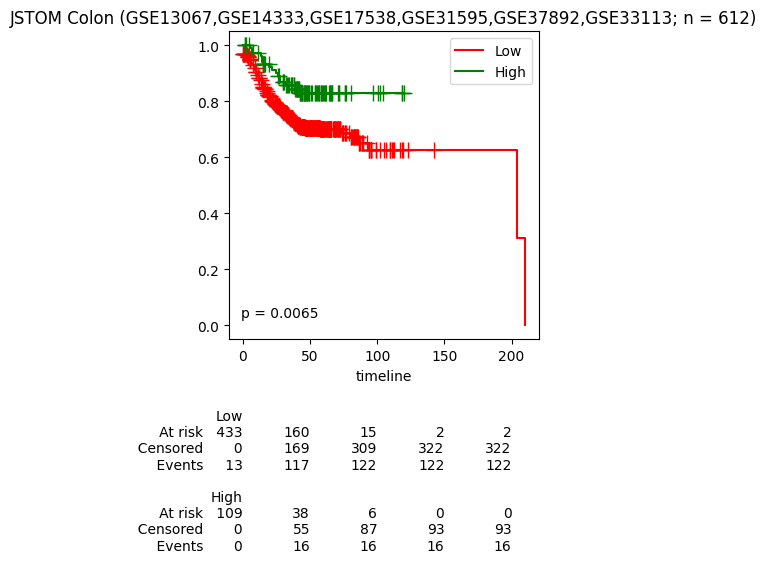

In [3]:
figure4a()

Hoshida 2013 Cir RMA (n = 216)
GSE15654 LIV15.2
216 [150, 66] GSE15654 LIV15.2
[80, 197, 205]
[-184.62868594282904, 143.06588201285965, -185.12868594282904, -184.12868594282904]
-184.62868594282904 9.582862537736185 7.433594845448042 -177.195091097381


<Axes: title={'center': 'Hoshida 2013 Cir RMA (GSE15654; n = 216)'}, xlabel='timeline'>

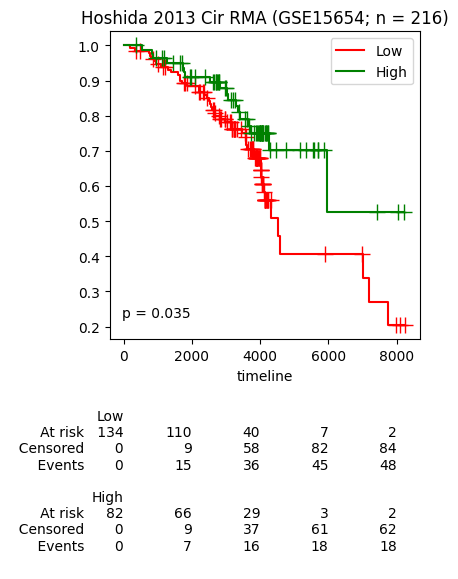

In [4]:
figure4b()

Scicluna 2015 Sepsis blood (n = 802)
GSE65682 MAC104
479 [365, 114] GSE65682 MAC104
[146]
[56.90242754761185, 191.4146805386916, 56.40242754761185, 57.40242754761185]
[26.422929041284288, 517.2102526817084, 25.922929041284288, 26.922929041284288]
56.90242754761185 2.711886580474211 11.422924121270158 37.84585316255445


<Axes: title={'center': 'Scicluna 2015 Sepsis blood (GSE65682; n = 802)'}, xlabel='timeline'>

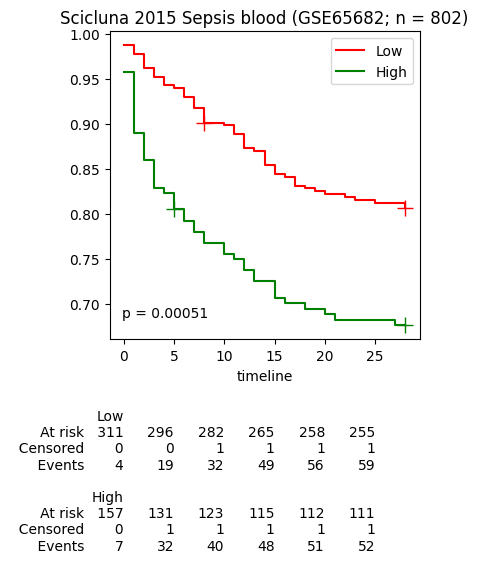

In [5]:
figure4c()

Herazo-Maya 2013 IPF I (n = 45)
GSE28221 MACV74
45 [30, 15] GSE28221 MACV74
[89, 398, 386]
[-807.8021095217158, 26.931909999923608, -808.3021095217158, -807.3021095217158] 33.74628102824738
-807.8021095217158
Herazo-Maya 2013 IPF II (n = 94)
GSE28221 MACV75
75 [32, 43] GSE28221 MACV75
[79, 255, 253]
[-332.447435931323, 40.43566281024927, -332.947435931323, -331.947435931323] 14.829800017078318
-346.447435931323


<Axes: title={'center': 'GSE28221'}, xlabel='timeline'>

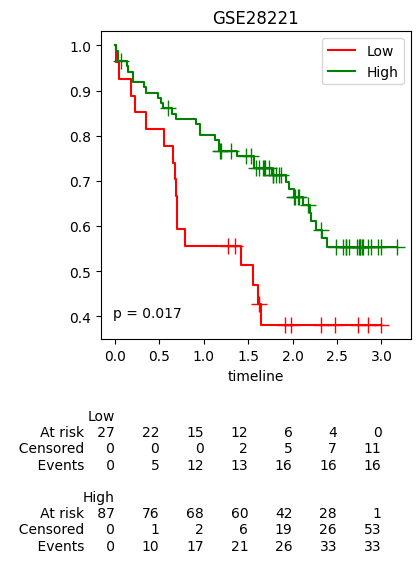

In [6]:
figure4d()

Einecke 2010 kidney transplant (n = 282)
GSE21374 MACV82
282 [231, 51] GSE21374 MACV82
[106]
[41.550733341143626, 162.11983180344308, 41.050733341143626, 42.050733341143626]
41.550733341143626 4.345710185670603 8.314333412435753 49.86506675357938


<Axes: title={'center': 'Einecke 2010 kidney transplant (GSE21374; n = 282)'}, xlabel='timeline'>

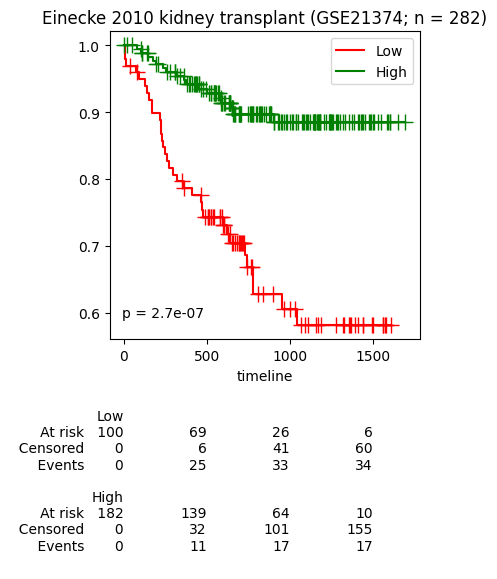

In [7]:
figure4e()

Zhang 2019 kidney transplant blood (n = 235)
GSE112927 MACV80
235 [205, 30] GSE112927 MACV80
[48]
[10.164892625203498, 110.4350962900807, 9.664892625203498, 10.664892625203498]
13.746316647580851 1.9196930749778796 3.711854993597197 13.876747618800696


<Axes: title={'center': 'Zhang 2019 kidney transplant blood (GSE112927; n = 235)'}, xlabel='timeline'>

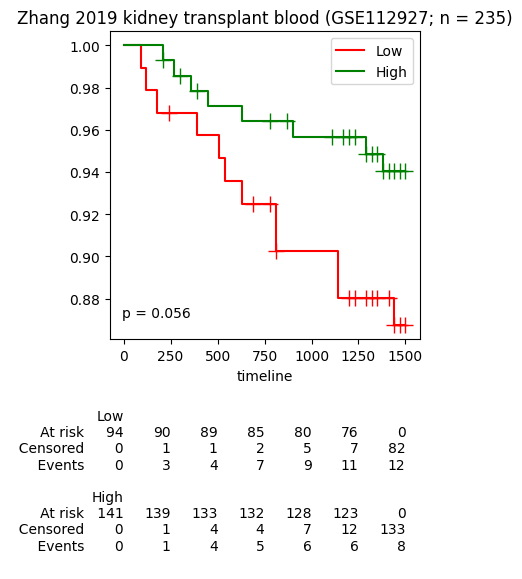

In [8]:
figure4f()

Kuparinen 2013 outcome (n = 151)
GSE65218 MACV120.2
151 [81, 70] GSE65218 MACV120.2
[92, 219, 219]
[-329.92369000867586, 60.23377651345173, -330.42369000867586, -329.42369000867586]
-328.1607450456189 18.925726647930535 13.820337048371982 -316.1033529603039
Kuparinen 2013 outcome (n = 151)
GSE65218 MACV120.2
151 [81, 70] GSE65218 MACV120.2
[92, 219, 219]


(<Axes: title={'center': 'Kuparinen 2013 outcome (GSE65218; n = 151)'}, xlabel='timeline'>,
 <Axes: xlabel='1', ylabel='2'>)

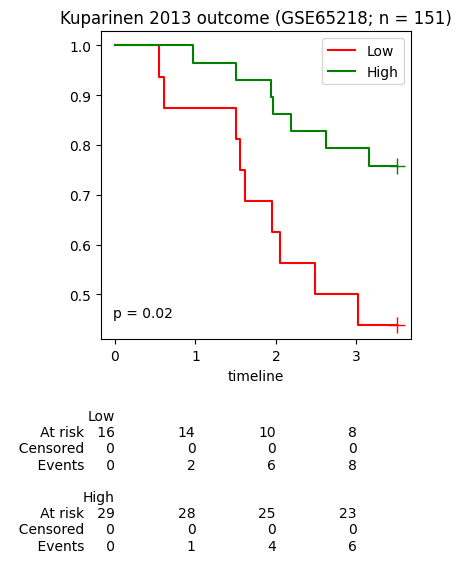

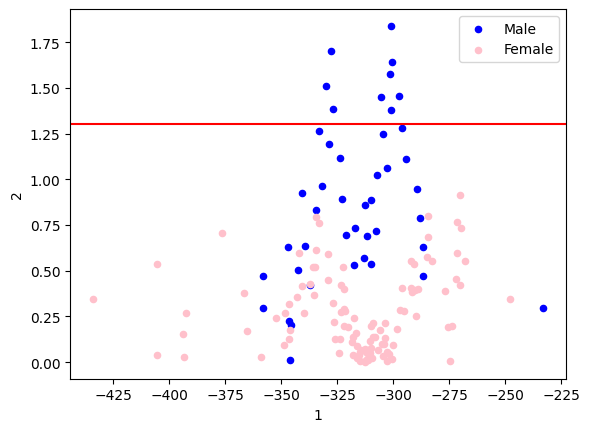

In [9]:
figure4g()